Best Params: {'C': 1, 'degree': 3, 'gamma': 'scale'}
Accuracy: 0.845
Confusion Matrix:
 [[79 10]
 [21 90]]


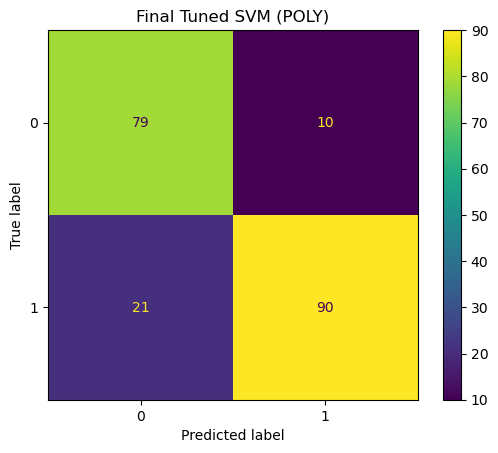

In [2]:
# Imports
import numpy as np
import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split, GridSearchCV
from sklearn.preprocessing import StandardScaler
from sklearn.svm import SVC
from sklearn.datasets import make_classification
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay, accuracy_score

# Dataset (same)
X, y = make_classification(n_samples=1000, n_features=10, n_classes=2, random_state=42)

# Split
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# Scaling (IMPORTANT)
scaler = StandardScaler()
X_train = scaler.fit_transform(X_train)
X_test = scaler.transform(X_test)
model = SVC(kernel='poly')

param_grid = {
    'C': [0.1, 1, 10],
    'degree': [2, 3, 4],
    'gamma': ['scale', 0.1, 0.01]
}
# GridSearch
grid = GridSearchCV(model, param_grid, cv=5)
grid.fit(X_train, y_train)

# Best params
print("Best Params:", grid.best_params_)
# Best model
best_model = grid.best_estimator_

# Prediction
y_pred = best_model.predict(X_test)

# Accuracy
print("Accuracy:", accuracy_score(y_test, y_pred))

# Confusion Matrix
cm = confusion_matrix(y_test, y_pred)
print("Confusion Matrix:\n", cm)

# Plot
disp = ConfusionMatrixDisplay(confusion_matrix=cm)
disp.plot()
plt.title("Final Tuned SVM (POLY)")
plt.show()